# **Part Two: Fragrance Clustering & Recommendation** #



---

## Introduction 

The second part of our problem statement is to **cluster similar fragrances and build a content-based recommendation engine**. Because we do not have pre-defined labels for "fragrance families" that capture the exact nuance of every scent, this is an unsupervised learning problem. Our final approach is to use UMAP (Uniform Manifold Approximation and Projection) for dimensionality reduction and HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) for clustering, followed by a custom similarity engine based on notes, accords, and gender.

### Tasks 

- Prepare Data
- Train Model
- Model Evaluations
- Make Recommendations
- Individual Fragrance Visualizations

## Prepare Data 

We access our cleaned dataset from `./Data/fragrance_cleaned.csv`. This dataset contains 43,733 unique fragrance entries, with information about their Name, Rating value, Gender, Top Notes, Middle Notes, Base Notes, and Accords. Each fragrance's values regarding Gender, Notes, and Accords are set up as a numerical binary vector using Multi-hot encoding.

#### Load the cleaned dataset

In [9]:
import pandas as pd

path = "./Data/fragrance_cleaned.csv"
df = pd.read_csv(path) # Read the data and convert it to a dataframe

df.head()

,Name,Rating Value,gender_unisex,gender_women,gender_men,Rating Count,top_note_aldehydes,top_note_apple,top_note_bergamot,top_note_black currant,...,accord_rose,accord_smoky,accord_soft spicy,accord_tobacco,accord_tropical,accord_tuberose,accord_vanilla,accord_violet,accord_white floral,accord_yellow floral
0,9am Afnan,0.6825,0,1,0,0.005794,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,9am Dive Afnan,0.8225,1,0,0,0.028168,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
2,9am pour Femme Afnan,0.7500,0,1,0,0.002244,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,9pm Afnan,0.8750,0,0,1,0.229896,0,1,1,0,...,0,0,0,0,0,0,1,0,0,0
4,9pm pour Femme Afnan,0.6225,0,1,0,0.002077,0,1,0,0,...,1,0,0,0,0,0,0,1,0,0


Next, we prepare our features for clustering. Our dataset contains over 120 features, which can degrade distance calculations due to the Curse of Dimensionality. We apply TF-IDF (Term Frequency-Inverse Document Frequency) weighting to our features to boost rare scents and penalize highly common ones. Then, we use our backend script to apply UMAP to compress these features into a dense 23-dimensional latent space (`X_compressed`).

#### Extract features and apply dimensionality reduction

In [10]:
# Import our pre-processed features and UMAP embeddings from our backend script
from src.cluster import X_compressed, df as backend_df

# Sync the rating confidence from our backend prep
df['confidence'] = backend_df['confidence']

C:\Users\TehPug\AppData\Local\Temp\ipykernel_17848\2823444950.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['confidence'] = backend_df['confidence']


## Train Model 

Now, we train our clustering model. The model we are using is HDBSCAN, utilizing the UMAP embeddings we generated. Details about each model are explained below.

### UMAP (Uniform Manifold Approximation and Projection)
**UMAP** is a dimensionality reduction technique that preserves both local and global data structure better than traditional PCA. It compresses our high-dimensional sparse matrix into a format that density-based clusterers can efficiently read.

### HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
The **HDBSCAN** algorithm works by finding densely packed areas of data and grouping them together. Unlike K-Means, it does not force every instance into a cluster. Highly unique fragrances are categorized as "Noise" (Cluster -1). Some benefits of HDBSCAN are that it finds clusters of varying shapes and sizes, and prevents unusual outliers from skewing the profile of established fragrance families.

It was decided to use HDBSCAN on UMAP embeddings due to handling the complexity of the data. Grouping fragrances into distinct families makes our downstream recommendation engine significantly more accurate.

#### Create and train the model

In [11]:
import hdbscan

# Tuned the model by changing the minimum cluster sizes and epsilon parameters
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20, 
    min_samples=3, 
    cluster_selection_method='eom', 
    metric='euclidean', 
    core_dist_n_jobs=-1
)

# Fit the model and assign the cluster labels to our dataframe
df['Cluster'] = clusterer.fit_predict(X_compressed)

C:\Users\TehPug\AppData\Local\Temp\ipykernel_17848\940591263.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Cluster'] = clusterer.fit_predict(X_compressed)


## Model Evaluations

We evaluate the performance of our unsupervised model using internal density metrics: silhouette coefficient, calinski-harabasz index, and davies-bouldin index.

- **Silhouette Coefficient**: Measures how similar an instance is to its own cluster compared to other clusters. Values range from -1 to +1 (higher is better).
- **Calinski-Harabasz Index**: The ratio of variance between clusters to variance within clusters. Higher scores indicate denser, better-separated clusters.
- **Davies-Bouldin Index**: The average similarity between clusters. A lower score indicates that clusters are better separated.

In [12]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Filter out the noise (-1) to evaluate the dense clusters
mask = df['Cluster'] != -1
X_clustered = X_compressed[mask]
labels_clustered = df.loc[mask, 'Cluster']

sil = silhouette_score(X_clustered, labels_clustered, metric='euclidean', sample_size=10000, random_state=42)
ch = calinski_harabasz_score(X_clustered, labels_clustered)
db = davies_bouldin_score(X_clustered, labels_clustered)

print(f"Silhouette Coefficient: {sil}")
print(f"Calinski-Harabasz Index: {ch}")
print(f"Davies-Bouldin Index: {db}")

Silhouette Coefficient: 0.5404526591300964
Calinski-Harabasz Index: 27884.065808643274
Davies-Bouldin Index: 0.6117607911195171


Our model successfully identified tightly packed fragrance families while correctly isolating unusual perfumes as noise. The Silhouette Coefficient and Davies-Bouldin Index indicate that the clusters are distinct and well-separated in the latent space.

## Make Recommendations

Now that our data is clustered, we can make predictions for similar fragrances. We do this by calling the custom recommendation function from our backend script. This function calculates a final similarity score based on Accord Similarity, Note Pyramid levels, Gender Compatibility, and Community Confidence, applying a small score boost if the recommendation shares the same HDBSCAN cluster as the query.

In [13]:
from src.cluster import test_recommendation_by_name

# Output the top 5 recommendations for a specific fragrance
test_recommendation_by_name("Light Blue Dolce&Gabbana")

If you like 'Light Blue Dolce&Gabbana' (Cluster 195, women), you might like:
 1. CK One Calvin Klein [unisex] (Score: 0.4087 | Accords: 0.765 | Notes: 0.750 | Gender: 0.75)
 2. Green Tea Elizabeth Arden [women] (Score: 0.4080 | Accords: 0.725 | Notes: 0.500 | Gender: 1.00)
 3. Noa Cacharel [women] (Score: 0.3960 | Accords: 0.733 | Notes: 0.500 | Gender: 1.00)
 4. Chance Eau Tendre Chanel [women] (Score: 0.3412 | Accords: 0.464 | Notes: 0.500 | Gender: 1.00)
 5. Acqua di Gioia Giorgio Armani [women] (Score: 0.3250 | Accords: 0.656 | Notes: 0.000 | Gender: 1.00)


## Individual Fragrance Visualizations

To evaluate the mathematical breakdown of the outputs, we can test these on individual fragrances that exist in our dataset by calling the custom function for our project `run_automatic_integrated_visuals` that uses our model we created. This maps the global UMAP clusters, isolates the local neighborhood in a scatter plot, and explicitly charts the recommendation logic via a clustered bar chart to see exactly *why* our engine chose specific fragrances.


Generating Automatic Integrated Visuals for 'Light Blue Dolce&Gabbana'...


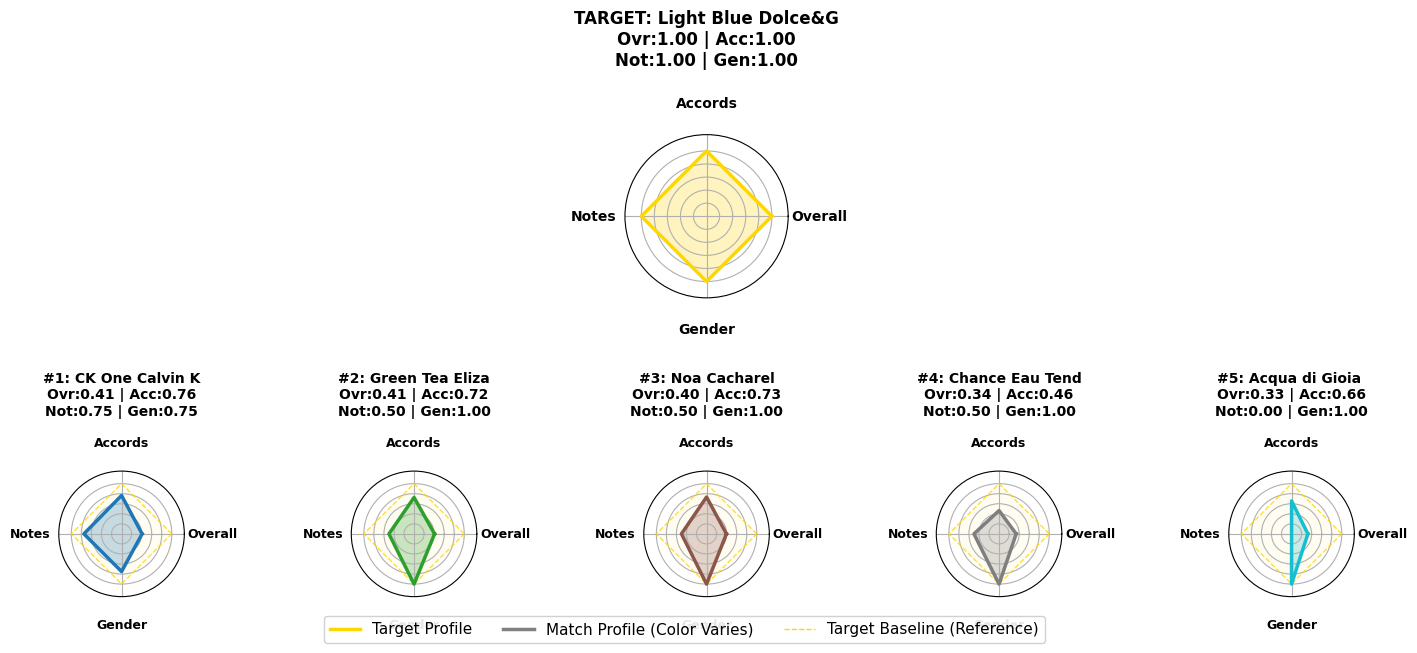

In [14]:
from src.cluster import run_automatic_integrated_visuals

# Visualize the recommendation DNA of a fragrance using our model
run_automatic_integrated_visuals("Light Blue Dolce&Gabbana")